# Cvičenie 3 - tvorba základnej neurónovej siete

Na tomto cvičení uvidíte, z čoho sa skladá jednoduchá (aj keď triviálna) neurónová sieť a ako ju pomocou Pytorchu implementovať.

## Ciele

1. Pochopiť, ako sú neurónové siete reprezentované v Pytorchi
2. Implementovať triviálnu sieť
3. Oboznámiť sa s konceptom akcelerácie pomocou GPU


## Zadanie

Oboznámte sa so spôsobom, ako sú neurónové siete implementované v rámci Pytorch. Podľa zadania následne vytvorte jednoduché neurónové siete s požadovanou štruktúrou a preštudujte vybrané aktivačné funkcie neurónových sietí. Následne si nainštalujte podporu technológie CUDA a vyskúšajte si jej využitie za pomoci rámca Pytorch.
___

## Krok 1 - neurónové siete - Pytorch reprezentácia

Pytoroch poskytuje prostriedky na vytváranie vlastných modelov neurónových sietí, ktoré sa nachádzajú v balíku **torch.nn**. Pre vytvorenie modelu stačí jednoducho rozšíriť triedu **nn.Module** a implementovať nasledujúce metódy:

1. **__init__(self)** - konštruktor, inicializujeme v ňom **vrstvy siete** (ľubovoľný počet/druh)
2. **forward(self, x)** - metóda operácií na vstupných dátach, tzv. **dopredný prechod**

### 1.1 - vytvorenie dvojvrstovej siete

Na nasledujúcom príklade si ukážeme, ako je možné vytvoriť triviálnu neurónovú sieť ktorá bude obsahovať nasledujúce vrstvy:

1. **Vstupná vrstva** - o veľkosti 10
2. **Výstupá vrstva** - o veľkosti 5

Vizualizácie siete:

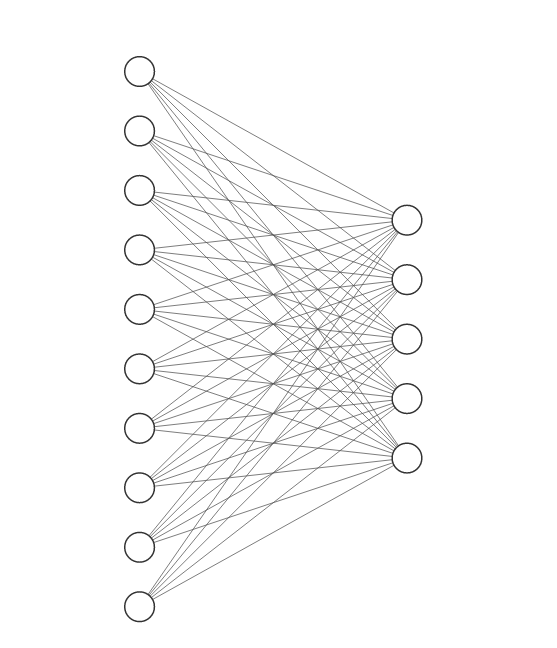

Implementácie siete:

##### *Spustiteľná ukážka*

In [ ]:
import torch
from torch import nn

class NeuralNetwork(nn.Module):
    # custom constructor
    def __init__(self):
        super(NeuralNetwork, self).__init__() # call inherited constructor

        # initialize network layers (one linear layer in this case)
        self.linear = nn.Linear(10, 5) # takes a tensor of length 10 as an input, returns tensor of length 5 

    # forward pass method (operations to do on input data)
    def forward(self, x):
        x = self.linear(x) # pass through linear layer
        x = torch.relu(x) # pass through an activation function
        
        return x

Takto sme vytvorili triviálnu neurónovú sieť, ktorá obsahuje len jednu lineárnu vrstvu s vstupnou veľkosťou 10 a výstupnou veľkosťou 5. Takáto vrstva slúži ako vstupná aj výstupná vrstva siete zároveň. Pri doprednom prechode dáta prejdú najprv lineárnou vrstvou, následne je na ne aplikovaná aktivačná funkcia relu (Rectified Linear Unit).

Pre prácu so sieťou je potrebné vytvorenú triedu inštantizovať. Následne môžete pozorovať štruktúru siete jednoduchým vypísaním do konzoly.

##### *Spustiteľná ukážka*

In [ ]:
model = NeuralNetwork()
print(model)

Ak chceme na sieť aplikovať dáta (vykonať predikciu), urobíme to nasledovne:

##### *Spustiteľná ukážka*

In [ ]:
x = torch.rand(10) # random 1D tensor of length 10
y = model(x)

print(y)

Ako vidíte, sieť na základe vstupných dát vo forme jednorozmerného tensora o dĺžke 10 vrátila výstupný jednorozmerný tensor o dĺžke 5, čo zodpovedá štruktúre lineárnej vrstvy siete, tak ako sme ju zadefinovali.

> ##### ***Poznámka***
*Musíte dbať na to aby dáta, ktoré vkladáte do siete mali kompatibilný tvar, ináč sieť vráti výnimku.*

##### *Spustiteľná ukážka*

In [ ]:
x = torch.rand(20) # random 1D tensor of length 20
y = model(x)

print(y)

### Úloha  č.1

Definujte a vytvorte sieť, ktorá bude akceptovať vstupné dáta vo forme definovaného tensora a obsahuje lineárnu výstupnú vrstvu o veľkosti 5. Veľkosť vstupnej vrstvy zistite na základe vstupných dát, nezabúdajte však na to, že **nn.Linear** akceptuje iba jednorozmerné dáta, preto (v implementácii dopredného prechodu), vstupný tensor správne pretvarujte (podľa cvičenia 1). Pozorujte, aké výstupné hodnoty sieť vracia na základe definovaného tensora.

In [ ]:
input_data = torch.rand(4,4)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # define the layers

    def forward(self, x):
        # implement the forward pass
        
        return x

___

### 1.2 - siete so skrytými vrstvami

Hore ste mohli vidieť príklad siete, ktorá obsahuje iba vstupnú a výstupnú vrstu. Neurónové siete môžu samozrejme obsahovať ľubovoľný počet vrstiev nachádzajúcich sa medzi týmito dvoma vrstvami - tzv. **skryté siete**. Hore implementovanú sieť rozšírime o jednu skrytú vrstvu o veľkosti **15**.

Vizualizácie siete:

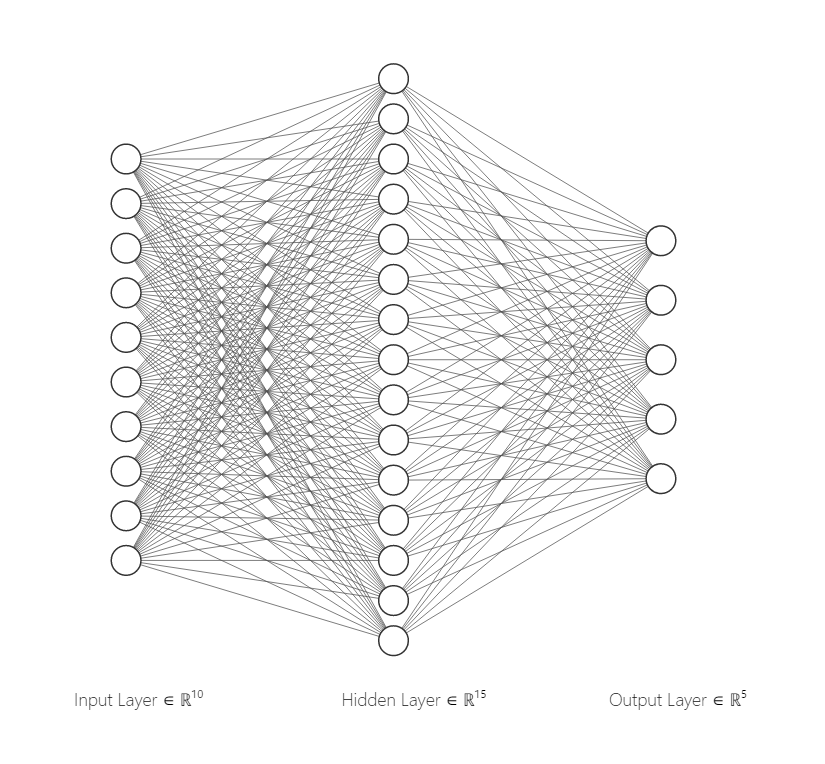

Implementácie siete:

##### *Spustiteľná ukážka*

In [ ]:
import torch
from torch import nn

class HiddenLayerNetwork(nn.Module):
    def __init__(self):
        super(HiddenLayerNetwork, self).__init__() 
        
        self.linear_hidden = nn.Linear(10, 15) # hidden layer of size 10 
        self.linear_output = nn.Linear(15, 5) # output layer of size 5

    def forward(self, x):
        x = self.linear_hidden(x) # pass through hidden layer
        x = torch.relu(x) 
        x = self.linear_output(x) # pass through hidden layer
        x = torch.relu(x) 
        
        return x
    
model = HiddenLayerNetwork()
print(model)

### Úloha č.2

*Sieť ktorú ste vytvorili v úlohe č.1 rozšírte o dve skryté vrstvy, o veľkostiach **20** a **10***

In [ ]:
input_data = torch.rand(4,4)

class NewNet(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # create the layres
        self.hidden1 = 
        self.hidden2 =  
        self.output =  

    def forward(self, x):
        # implement the forward pass
        
        return x

___

### 1.3 - veľkosti vrstiev ako parametre konštruktora

Vyššie ste mohli vidieť príklady sietí, ktoré obsahovali lineárne vrstvy o rôznych veľkostiach. Vo všetkých prípadoch sme veľosti vrstiev zapisovali "napevno", priamo pri vytváraní ich objektov v konštruketore triedy našej siete. Dobrým zvykom však býva tieto veľkosti implementovať ako parametre konštruktora siete a ich hodnoty definovať pred vytváraním objektu siete, ako tzv. **metaparametre**. Umožňuje to jednoduchšie ladenie sietí pri práci s nimi, preto vám odporúčame pri riešení ďalších úloh preferovať takýto spôsobo tvorenia sietí.

Ukážka na hore implementovaej siete **HiddenLayerNetwork**:

##### *Spustiteľná ukážka*

In [ ]:
import torch
from torch import nn

class HiddenLayerNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(HiddenLayerNetwork, self).__init__() 
        
        self.linear_hidden = nn.Linear(input_size, hidden_size) 
        self.linear_output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.linear_hidden(x)
        x = torch.relu(x) 
        x = self.linear_output(x)
        x = torch.relu(x) 
        
        return x

# metaparameters
input_size = 10
hidden_size = 15
output_size = 5

model = HiddenLayerNetwork(input_size, hidden_size, output_size)
print(model)

### Úloha č.3

Refaktorujte vami vytvorenú sieť z úlohy č.2 tak, aby zodpovedala hore ukázanému prístupu vytvárania sietí. Do kódu dplňte parametre siete, vytvorenie jej vrstiev a dopredný prechod.

In [ ]:
class NewNet(nn.Module):
    def __init__(self, _ ): # add parameters
        super(NewNet, self).__init__()
        self.hidden1 = 
        self.hidden2 = 
        self.output = 

    def forward(self, x):
        # define forward pass
        
        return x

___

## Krok 2 - aktivačné funkcie

Ako ste si mohli všimnúť, v hore uvedených ukážkach bol viac krát použitý koncept **aktivačných funkcií**. Aktivačné funkcie sú jedným zo základných kameňov neurónových sietí a teda majú rozsiahlu podporu v knižnici Pytorch. Z matematického hľadiska sú aktivačné funkcie funkcie, ktoré príjmajú ako vstup numerický výstup neurónu, aplikujú naňho matematickú operáciu a výsledná hodnota je použitá ako vstup pre neuróny nasledujúcej vrstvy siete. 

Na nižšie uvedených ukážkach môžete vidieť príklady rôznych aktivačných funkcií ponúkaných knižnicou Pytorch. Ich plný zoznam a špecifikáciu, spolu s matematickými definíciami, si môžete prečítať na týchto linkoch: [link 1](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity), [link 2](https://pytorch.org/docs/stable/nn.html#non-linear-activations-other).

### 2.1 ReLU

<img src="./Images/relu.png" style="width: 400px;"/>

##### *Spustiteľná ukážka*

In [ ]:
import torch
import torch.nn as nn

# 10 random values between -5 and 5
x = torch.rand(10) * 10 - 5 

# values passed through the activation function
output = torch.relu(x)

print(f"Input values: \n{x}\n")
print(f"Activation function output: \n{output}")

___

### 2.2 Sigmoid

<img src="./Images/sigmoid.png" style="width: 400px;"/>

##### *Spustiteľná ukážka*

In [ ]:
import torch
import torch.nn as nn

# 10 random values between -5 and 5
x = torch.rand(10) * 10 - 5 

# values passed through the activation function
output = torch.sigmoid(x)

print(f"Input values: \n{x}\n")
print(f"Activation function output: \n{output}")

___

### 2.3 Tanh

<img src="./Images/tanh.png" style="width: 400px;"/>

##### *Spustiteľná ukážka*

In [ ]:
import torch
import torch.nn as nn

# 10 random values between -5 and 5
x = torch.rand(10) * 10 - 5 

# values passed through the activation function
output = torch.tanh(x)

print(f"Input values: \n{x}\n")
print(f"Activation function output: \n{output}")

### Úloha č.4

Vytvorte novú sieť s rovnakou štruktúrou vrstiev ako sieť, ktorú ste vytvorili v **úlohe č.3**. V novej sieti ale použite aktivačnú fukncie **tanh**. Nakoniec vykonajte pomocou oboch sietí predikciu na rovnakých náhodných dátach a porovnajte, či to ovplyvnilo výsledok predikcie.

In [ ]:
class NewNetTanh(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(NewNetTanh, self).__init__()
        # define zhe layers (same as NewNet)
        self.hidden1 = 
        self.hidden2 = 
        self.output = 

    def forward(self, x):
        # define the forward pass (with tahn instead of relu)
        
        return x
    

model1 = NewNet(16, 20, 10, 5)
model2 = NewNetTanh(16, 20, 10, 5)

input_data = torch.rand(4,4)

y1 = model1(input_data)
y2 = model2(input_data)

print(y1)
print(y2)

___

## Krok 3 - CUDA

Mnohé procesy strojovéhu učenia, od trénovania sietí po vykonávanie predikcií, je možné výrazne zefektívniť použítím **paralelizmu**. Práve s tým vedia pomôcť mnohé moderné grafické procesory (GPU), ktoré na rozdiel od CPU podporujú širokú mieru masívneho paralelizmu. Ak vaše zariedenie obsahuje tzv. "Cuda-enabled GPU", t.j. GPU od výrobcu Nvidia, obsahujúce CUDA funkcionalitu, môžete ho využiť vďaka podpore platformy CUDA knžnicou Pytorch. 

### 3.1 - kompatibilita a inštalácia

To, či vaše zariadenie obsahuje takéto GPU zistíte tak, že ho nájdete na [oficiálnom zozname](https://developer.nvidia.com/cuda-gpus) podporovaných GPU. Ak Takéto GPU vlastníte, môžete si nainštalovať [**CUDA Toolkit**](https://developer.nvidia.com/cuda-toolkit), ktorý vám umožní ho využívať pri práci s knižnicou Pytorch. Po nainštalovaní CUDA Toolkitu dbajte na to, aby ste si pri inštalácii Pytorch-u zvolili možnosť s podporou CUDA na [stránke s inštalačnými príkazmi](https://pytorch.org/get-started/locally/).

___

### 3.2 - overenie inštalácie

Ak pracujete s CUDA-enabled GPU a máte nainštalované potrebné balíky pre prácu s ním, môžete ho začať používať pri riešení úloh, ktoré budú náplňou tohto predmetu. To umožňuje rozhranie *pytorch.cuda*. Prácu s ním môžete vidieť na nasledujúcej ukážke, ktorá využíva nasledujúce metódy:

1. **is_available()** - vráti hodnotu *true* alebo *false*, na základe toho, či vaše zariadenie podporuje CUDA
2. **current_device()** - vráti id používaného CUDA zariadenia
3. **get_device_name(id)** - vráti názov CUDA zariadenia podľa jeho ID 

##### *Spustiteľná ukážka*

In [ ]:
import torch

print(f"Is CUDA supported by this system? {torch.cuda.is_available()}")

if (torch.cuda.is_available()): 
    cuda_id = torch.cuda.current_device()

    print(f"ID of current CUDA device: {cuda_id}")
    print(f"Name of current CUDA device: {torch.cuda.get_device_name(cuda_id)}")

___

### 3.3 - práca s dátami

Ak chcete prácu s dátami a modelmi vykonávať na GPU, musíte ich prekonvertovať na príslušný typ pomocou metódy **to(device)**. Paremeter **device** je objekt reprezentujúci zariadenie, v ktorého pamäti sú dané dáta ukladané, t.j. CPU alebo GPU. Nasledujúca ukážka predstavuje konverziu na príklade jednoduchého tensoru.

##### *Spustiteľná ukážka*

In [ ]:
x = torch.rand(10)

if (torch.cuda.is_available()):
    device = torch.device('cuda')
    print("Your pc is cuda-enabled, will move tensor to GPU")
else:
    device = torch.device('cpu')
    print("Your pc is not cuda-enabled, tensor will remain in CPU")
    
x = x.to(device)
print(f"Tensor is on device {x.device}")



Môžete si všimnúť, že ak je vaše GPU cuda-enabled, nastavil sa device na *cuda:0*